In [313]:
import torch
import torch.nn.functional as F 
import matplotlib.pyplot as plt 

In [314]:
words = open("names.txt", "r").read().splitlines()
words[:3]

['emma', 'olivia', 'ava']

In [315]:
chars = sorted(list(set("".join(words))))

stoi = {s: i+1 for i, s in enumerate(chars)}
stoi["."] = 0 

itos = {i:s for s, i in stoi.items()}

In [316]:
# Build the dataset 
block_size = 3 
X, Y = [], [] 

for w in words:
   # print(w)

    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        #print("".join(itos[i] for i in context), "---->", itos[ix])
        context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y)

In [317]:
# build the dataset and split into training, def/val and test sets 

def build_dataset(words):
    block_size = 3 
    X, Y = [], [] 

    for w in words:
        context = [0] * block_size 
        for ch in w + ".":
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
    
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random 
random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [318]:
Xtr.shape, Ytr.shape

(torch.Size([182625, 3]), torch.Size([182625]))

In [332]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 2), generator=g)
W1 = torch.randn((6, 300), generator=g)
b1 = torch.randn(300, generator=g)
W2 = torch.randn((300, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [334]:
sum(p.nelement() for p in parameters) # total number of paramters 

10281

In [335]:
for p in parameters: 
    p.requires_grad = True 

In [322]:
# Since we have figured out the range where we think lies the optimal learning rate, we create a range of values between those two points 


# lr = torch.linspace(0.001, 1, steps=1000)

# This is a better way of re-implementing the code above 
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [354]:
lri = []
lossi = [] 
stepi = [] 

for i in range(30000):

    # mini-batch construct 
    ix = torch.randint(0, Xtr.shape[0], (32,))

    # forward pass 
    # C[x[ix]] means we only want 32 rows of X which we will the be used to be indexed in C
    emb = C[Xtr[ix]] # (32, 3, 2)
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
    logits = h @ W2 + b2 # (32, 27)


    # counts = logits.exp()
    # probs = counts / counts.sum(1, keepdims=True)
    # loss = -probs[torch.arange(32), Y].log().mean()

    # this one line of code is equivalent the the three commented lines above 
    # Y[ix] also select does same 32 rows corresponding Y label values 
    loss = F.cross_entropy(logits, Ytr[ix])
    #print(loss.item())

    # backward pass 
    for p in parameters:
        p.grad = None

    loss.backward() 
    # update 
    #lr = lrs[i]

    # main lr 
    #lr = 0.1

    # lr decay
    lr = 0.01

    for p in parameters: 
        p.data -= lr * p.grad 
    
    # track stats 
    #lri.append(lre[i])
    lossi.append(loss.item())
    stepi.append(i)

# Training loss 
loss

tensor(2.2171, grad_fn=<NllLossBackward0>)

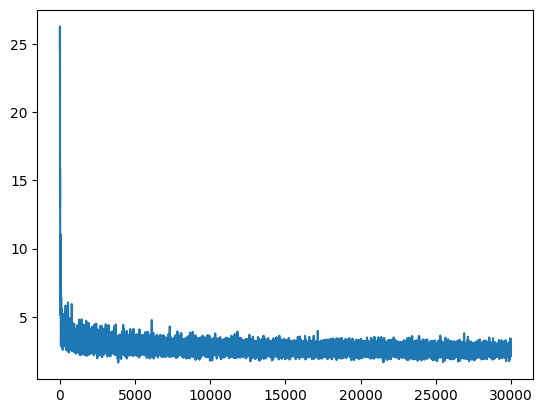

In [337]:
plt.plot(stepi, lossi)

In [355]:
# dev set loss 
emb = C[Xdev] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.2469, grad_fn=<NllLossBackward0>)

In [356]:
# Training set loss - The network has already been trained on this set 
# if this is lower than the dev set, we can say that the model is overfitting 
emb = C[Xtr] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ytr)
loss

tensor(2.2382, grad_fn=<NllLossBackward0>)

In [326]:
# plot lri and lossi 
# plt.plot(lri, lossi)

In [327]:
# generate mini-batches 
# Select 32 training examples from X which will be 32 indexes 
torch.randint(0, X.shape[0], (32,))

tensor([ 64084,  76045, 174370, 153304,  98698, 220880, 126963, 210278, 116050,
         36915, 143199, 220783,  68786,  54748,  81416, 108498,  21638, 120777,
        123054, 180124,  93788,  81115,  88790, 214022,   5012, 189262, 203349,
        137385, 188169, 200798,  62767, 151523])

In [328]:
# Splitting the dataset 

# training set - it is used to optimize the parameters of the model (like the model weights using gradient descent) - 80%
# dev/validation set - it is used to develop or train all the hyperparameters 
#                           - like the size of a hidden layer,
#                           - the size of the embedding, 
#                           - or the strength of regularization, etc 
# test set - It is used to evaluate the overall performance of the model at the end